In [7]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [8]:
df.head(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [9]:
df.columns

Index(['job_title_short', 'job_title', 'job_location', 'job_via',
       'job_schedule_type', 'job_work_from_home', 'search_location',
       'job_posted_date', 'job_no_degree_mention', 'job_health_insurance',
       'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg',
       'company_name', 'job_skills', 'job_type_skills'],
      dtype='str')

In [10]:
df_companies = pd.DataFrame({
    "company_name": ["Google", "Microsoft", "Apple", "Nike", "Starbucks"],
    "industry": ["Technology", "Technology", "Technology", "Apparel", "Food & Beverage"],
    "company_size": ["100,000+", "100,000+", "100,000+", "75,000+", "346,000+"]
})

In [11]:
df_companies

,company_name,industry,company_size
0,Google,Technology,"100,000+"
1,Microsoft,Technology,"100,000+"
2,Apple,Technology,"100,000+"
3,Nike,Apparel,"75,000+"
4,Starbucks,Food & Beverage,"346,000+"


In [12]:
df_jobs = pd.DataFrame({
    "job_id": [1, 2, 3, 4, 5],
    "job_title": [
        "Data Scientist",
        "Software Engineer",
        "Product Manager",
        "Marketing Director",
        "HR Manager"
    ],
    "company_name": [
        "Google",
        "Microsoft",
        "Apple",
        "Nike",
        "Starbucks"
    ],
    "job_location": [
        "Mountain View, CA",
        "Redmond, WA",
        "Cupertino, CA",
        "Beaverton, OR",
        "Seattle, WA"
    ]
})

df_jobs

,job_id,job_title,company_name,job_location
0,1,Data Scientist,Google,"Mountain View, CA"
1,2,Software Engineer,Microsoft,"Redmond, WA"
2,3,Product Manager,Apple,"Cupertino, CA"
3,4,Marketing Director,Nike,"Beaverton, OR"
4,5,HR Manager,Starbucks,"Seattle, WA"


In [13]:
df_jobs.merge(df_companies, on='company_name')

,job_id,job_title,company_name,job_location,industry,company_size
0,1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
2,3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
3,4,Marketing Director,Nike,"Beaverton, OR",Apparel,"75,000+"
4,5,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,"346,000+"


In [14]:
df_india = df[df['job_location'] == 'India'].copy()

In [15]:
df_india['job_posted_month'] = df['job_posted_date'].dt.strftime('%B') 


In [16]:
df_india_pivot = df_india.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

In [17]:
df_india_pivot.reset_index(inplace=True)
df_india_pivot['Month_no'] = pd.to_datetime(df_india_pivot['job_posted_month'], format='%B').dt.month

df_india_pivot.sort_values('Month_no', inplace=True)
df_india_pivot.set_index('job_posted_month', inplace=True)
df_india_pivot.drop(columns='Month_no', inplace=True)

In [18]:
df_india_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,36,3,146,185,129,5,24,34,33,20
February,43,2,106,134,77,6,25,35,14,13
March,27,6,86,141,102,3,25,35,18,30
April,59,2,116,132,83,3,31,20,20,22
May,70,2,148,113,102,4,31,23,13,20
June,94,7,188,142,149,6,45,31,32,20
July,89,4,243,149,158,8,43,38,28,14
August,73,6,242,166,176,6,44,49,39,25
September,49,6,192,195,181,8,30,44,27,24


In [19]:
from datasets import load_dataset
import pandas as pd
df_us_software_pivot = pd.read_csv("https://lukeb.co/software_csv",index_col='job_posted_month')

In [20]:
df_us_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [22]:
df_india_merged = df_india_pivot.merge(df_us_software_pivot, on ='job_posted_month')

In [ ]:
top_5 = (df_india_merged
.sum()
.sort_values(ascending=False)
.head(5)
.index
.to_list()
)

top_5 

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer',
 'Data Analyst']

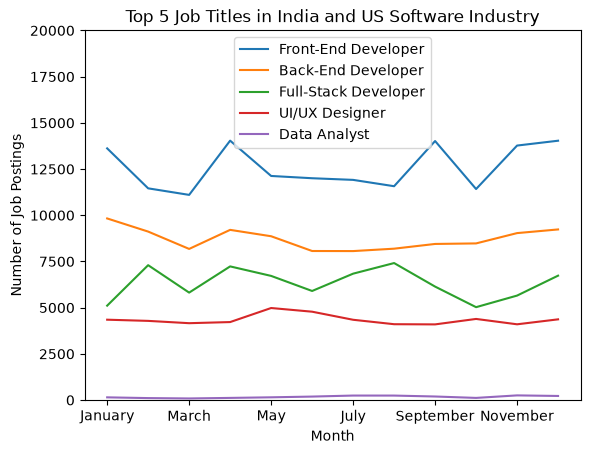

In [28]:
df_india_merged[top_5].plot(kind='line')
plt.title('Top 5 Job Titles in India and US Software Industry')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.ylim(0, 20000)
plt.legend()
plt.show()